In [1856]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [1857]:
df=pd.read_csv('heart_disease_data.csv')

In [1858]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [1859]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [1860]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

<Axes: xlabel='trestbps'>

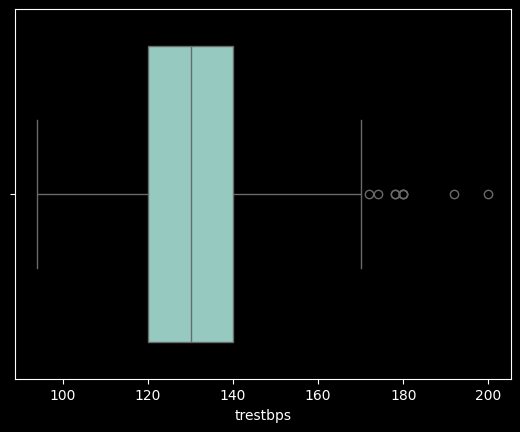

In [1861]:
sns.boxplot(x=df.trestbps)

<Axes: xlabel='chol'>

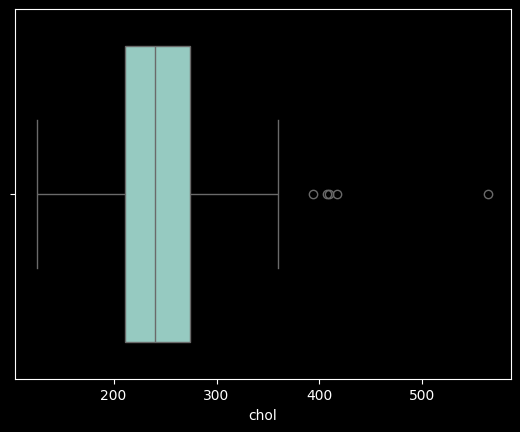

In [1862]:
sns.boxplot(x=df.chol)

<Axes: xlabel='thalach'>

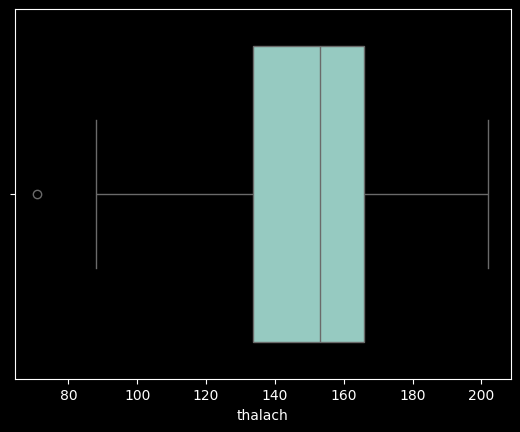

In [1863]:
sns.boxplot(x=df.thalach       )

<Axes: xlabel='thal'>

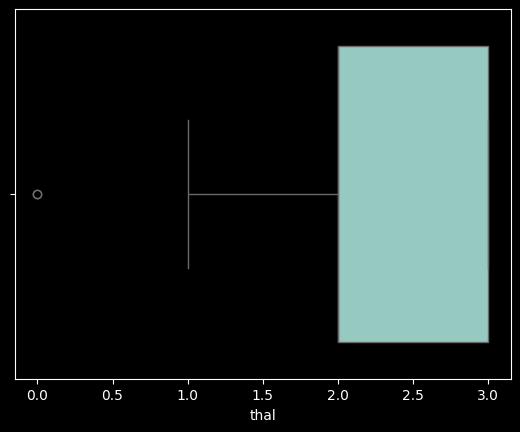

In [1864]:
sns.boxplot(x=df.thal)

In [1865]:
# q1 = df['trestbps'].quantile(0.25)
# q2 = df['trestbps'].quantile(0.75)
# rng=q2-q1
# lower=q1 - 1.5*rng
# upper=q2 + 1.5*rng
# df['trestbps'] = df['trestbps'].clip(lower=lower, upper=upper)

<Axes: xlabel='trestbps'>

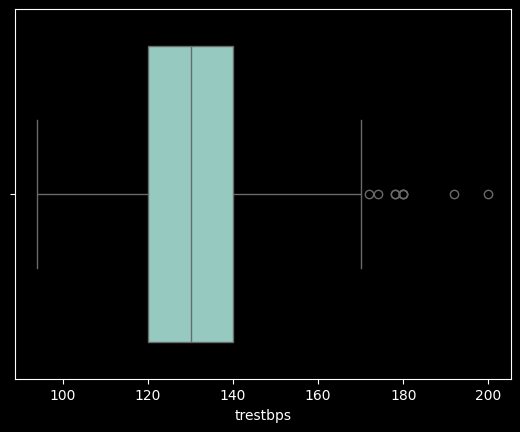

In [1866]:
sns.boxplot(x=df.trestbps)

In [1867]:
# q1 = df['chol'].quantile(0.25)
# q2 = df['chol'].quantile(0.75)
# rng=q2-q1
# lower=q1 - 1.5*rng
# upper=q2 + 1.5*rng
# df['chol'] = df['chol'].clip(lower=lower, upper=upper)

<Axes: xlabel='chol'>

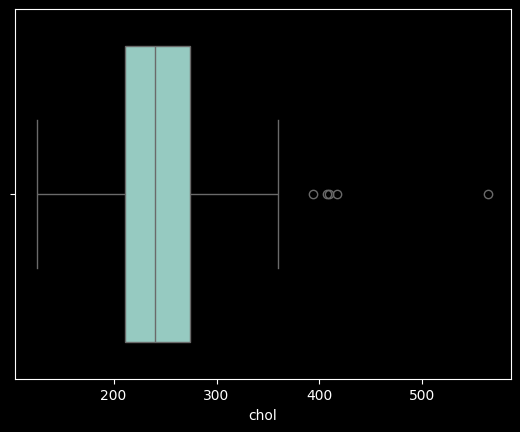

In [1868]:
sns.boxplot(x=df.chol)

In [1869]:
# q1 = df['thalach'].quantile(0.25)
# q2 = df['thalach'].quantile(0.75)
# rng=q2-q1
# lower=q1 - 1.5*rng
# upper=q2 + 1.5*rng
# df['thalach'] = df['thalach'].clip(lower=lower, upper=upper)

<Axes: xlabel='thalach'>

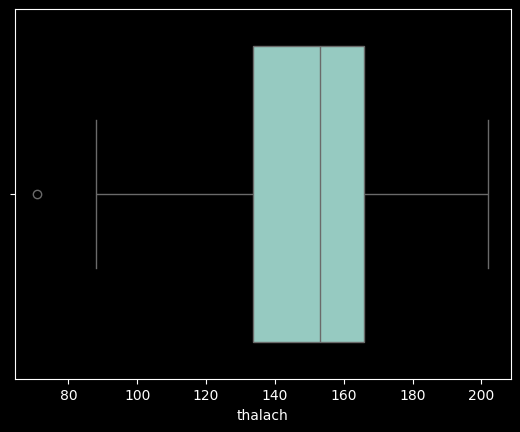

In [1870]:
sns.boxplot(x=df.thalach)

<Axes: xlabel='thalach', ylabel='Count'>

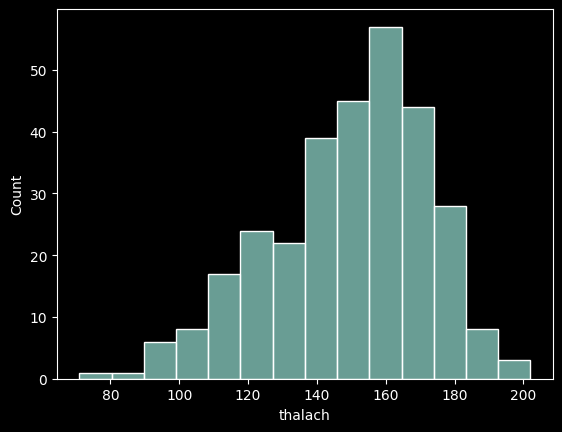

In [1871]:
sns.histplot(x=df.thalach)

In [1872]:
df.thalach.skew()

-0.5374096526832253

In [1873]:
# q1 = df['oldpeak'].quantile(0.25)
# q2 = df['oldpeak'].quantile(0.75)
# rng=q2-q1
# lower=q1 - 1.5*rng
# upper=q2 + 1.5*rng
# df['oldpeak'] = df['oldpeak'].clip(lower=lower, upper=upper)

<Axes: xlabel='oldpeak'>

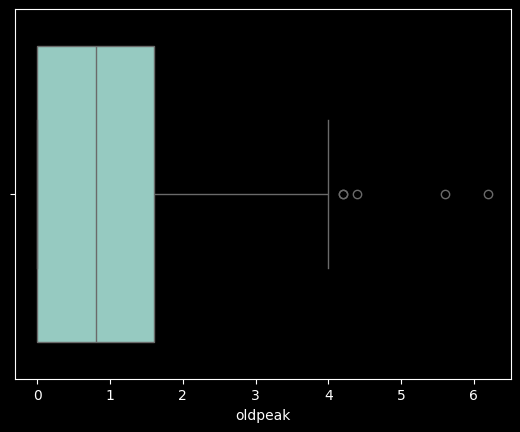

In [1874]:
sns.boxplot(x=df.oldpeak)

<Axes: xlabel='oldpeak', ylabel='Count'>

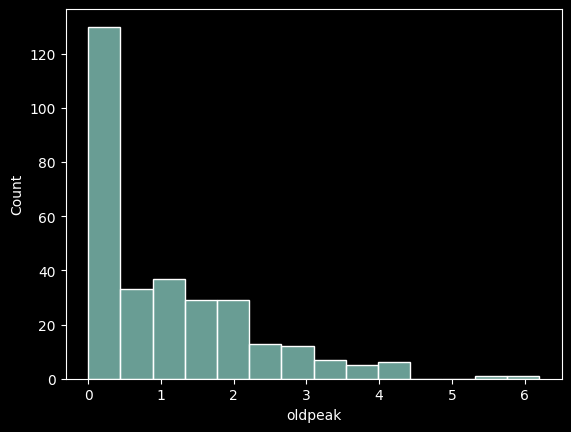

In [1875]:
sns.histplot(x=df.oldpeak)

In [1876]:
df.oldpeak.skew()

1.269719930601997

In [1877]:
df['oldpeak'] = np.sqrt(df['oldpeak'])
print(df['oldpeak'].skew())

0.1604670822515483


In [1878]:
q1 = df['thal'].quantile(0.25)
q2 = df['thal'].quantile(0.75)
rng=q2-q1
lower=q1 - 1.5*rng
upper=q2 + 1.5*rng
df['thal'] = df['thal'].clip(lower=lower, upper=upper)

<Axes: xlabel='thal'>

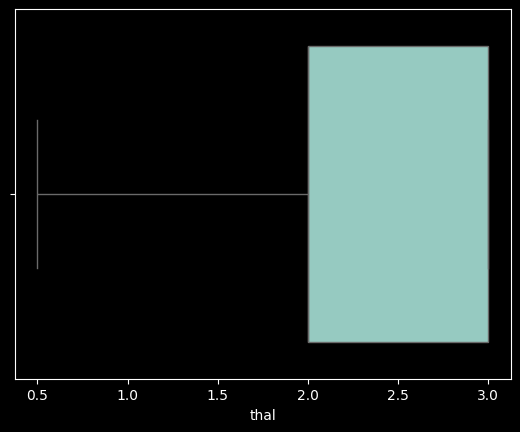

In [1879]:
sns.boxplot(x=df.thal)

In [1880]:
df.thal.skew()

-0.3235304108056243

In [1881]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler , StandardScaler ,OneHotEncoder
# ct=ColumnTransformer(
#     transformers=[
#         ('t1',MinMaxScaler(),['thalach']),
#         ('t2',StandardScaler(),['age','trestbps','chol','oldpeak']),
#     ],remainder='passthrough'
# )
# ct = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), ['age','trestbps','chol','thalach','oldpeak']),
#         ('ohe',OneHotEncoder(drop='first'),['sex','cp','thal','ca'])
#     ],
#     remainder='passthrough'
# )

from sklearn.base import BaseEstimator, TransformerMixin

class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.bounds = {}

    def fit(self, X, y=None):
        for col in X.columns:
            q1 = X[col].quantile(0.25)
            q3 = X[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            self.bounds[col] = (lower, upper)
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            lower, upper = self.bounds[col]
            X[col] = X[col].clip(lower, upper)
        return X
    
    


In [1882]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
from sklearn.pipeline import Pipeline

num_cols = ['age','trestbps','chol','thalach','oldpeak']
cat_cols = ['sex','cp','thal','ca']

num_pipeline = Pipeline([
    ('clipper', OutlierClipper()),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test=train_test_split(df.drop(['target'],axis=1) , df.target , test_size=0.2)
x=df.drop(['target'],axis=1)
y=df.target
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

In [1883]:
from sklearn.metrics import accuracy_score , confusion_matrix , recall_score , precision_score
confusion_matrix(y_test,y_pred)

array([[27,  4],
       [ 3, 27]], dtype=int64)

In [1884]:
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.8852459016393442
0.9
0.8709677419354839


In [1885]:
import joblib

# Save
joblib.dump(model, 'heart_model.pkl')

['heart_model.pkl']